In [1]:
2+3

5

In [2]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import segmentation_models_pytorch as smp
from tqdm import tqdm

/home/suryakrishnakishore/Documents/Hackbyte/Project/HackByte4.0/ImageAuthentication/image-auth-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class TamperingDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)

        # Handle different mask extensions
        base = os.path.splitext(img_name)[0]

        mask_path_png = os.path.join(self.mask_dir, base + ".png")
        mask_path_jpg = os.path.join(self.mask_dir, base + ".jpg")
        mask_path_jpeg = os.path.join(self.mask_dir, base + ".jpeg")

        # Select correct mask
        if os.path.exists(mask_path_png):
            mask_path = mask_path_png
        elif os.path.exists(mask_path_jpg):
            mask_path = mask_path_jpg
        elif os.path.exists(mask_path_jpeg):
            mask_path = mask_path_jpeg
        else:
            raise FileNotFoundError(f"Mask not found for {img_name}")

        # Read image
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Image not readable: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (128, 128)) / 255.0  # faster version

        # Read mask
        mask = cv2.imread(mask_path, 0)
        if mask is None:
            raise ValueError(f"Mask not readable: {mask_path}")

        mask = cv2.resize(mask, (128, 128))
        mask = (mask > 0).astype(np.float32)

        image = torch.tensor(image).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [4]:
train_dataset = TamperingDataset(
    "../dataset_small/train/images",
    "../dataset_small/train/masks"
)

val_dataset = TamperingDataset(
    "../dataset/val/images",
    "../dataset/val/masks"
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
model = smp.Unet(
    encoder_name="efficientnet-b0",  # 🔥 faster
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

In [6]:
import torch.nn as nn
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1.
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

NameError: name 'model' is not defined

In [21]:
EPOCHS = 3
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader):
        images, masks = images.to(device), masks.to(device)

        preds = model(images)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = loss_fn(preds, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved")

100%|██████████| 30000/30000 [12:05<00:00, 41.34it/s]


Epoch 1 | Train: 0.7165 | Val: 0.6600
✅ Best model saved


100%|██████████| 30000/30000 [12:25<00:00, 40.25it/s]


Epoch 2 | Train: 0.6659 | Val: 0.6559
✅ Best model saved


100%|██████████| 30000/30000 [12:28<00:00, 40.06it/s]


Epoch 3 | Train: 0.6399 | Val: 0.6508
✅ Best model saved


In [22]:
for param in model.encoder.parameters():
    param.requires_grad = True

print("✅ Encoder unfrozen")

✅ Encoder unfrozen


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

# Load your previously saved best model
model.load_state_dict(torch.load("/home/suryakrishnakishore/Documents/Hackbyte/Project/HackByte4.0/backend/models/best_model_finetuned.pth", map_location=device))

model.to(device)
model.train()

print("✅ Loaded previous best model")

✅ Loaded previous best model


In [9]:
for param in model.encoder.parameters():
    param.requires_grad = True

print("🔥 Encoder unfrozen for fine-tuning")

🔥 Encoder unfrozen for fine-tuning


In [10]:
import torch.nn as nn

bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1.
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def loss_fn(pred, target):
    return 0.7 * bce(pred, target) + 0.3 * dice_loss(pred, target)

# IMPORTANT: new optimizer with lower LR
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [12]:
EPOCHS = 2
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    # ===== TRAIN =====
    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader):
        images, masks = images.to(device), masks.to(device)

        preds = model(images)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===== VALIDATE =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = loss_fn(preds, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"[Fine-tune] Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # ===== SAVE BEST =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model_finetuned.pth")
        print("🔥 Improved model saved")

    else:
        print("⚠️ No improvement — consider stopping early")

100%|██████████| 30000/30000 [16:47<00:00, 29.78it/s]


[Fine-tune] Epoch 1 | Train: 0.2333 | Val: 0.2411
🔥 Improved model saved


100%|██████████| 30000/30000 [16:58<00:00, 29.47it/s]


[Fine-tune] Epoch 2 | Train: 0.2257 | Val: 0.2343
🔥 Improved model saved


In [13]:
def detect_tampering(image_path):
    # ===== LOAD IMAGE =====
    image = cv2.imread(image_path)
    original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = original.shape[:2]

    # ===== PREPROCESS =====
    img = cv2.resize(original, (128, 128), interpolation=cv2.INTER_AREA) / 255.0
    img = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float().to(device)

    # ===== MODEL =====
    with torch.no_grad():
        pred = model(img)
        heatmap = torch.sigmoid(pred).cpu().squeeze().numpy()

    # ===== POSTPROCESS =====
    heatmap = cv2.resize(heatmap, (w, h))

    # Smooth
    heatmap = cv2.GaussianBlur(heatmap, (5,5), 0)

    # Binary mask
    mask = (heatmap > 0.3).astype(np.uint8)

    # ===== DECISION =====
    tampered = "YES" if (heatmap.mean() > 0.04 or heatmap.max() > 0.6) else "NO"

    return original, heatmap, mask, tampered

In [14]:
model.eval()

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

In [15]:
import matplotlib.pyplot as plt

def show_result(image_path):
    original, heatmap, mask, tampered = detect_tampering(image_path)

    # Overlay
    overlay = original.copy()
    overlay = (overlay * 0.6 + (heatmap[..., None]*255) * 0.4).astype(np.uint8)

    plt.figure(figsize=(16,5))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Heatmap")
    plt.imshow(heatmap, cmap='hot')
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title(f"Tampered: {tampered}")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

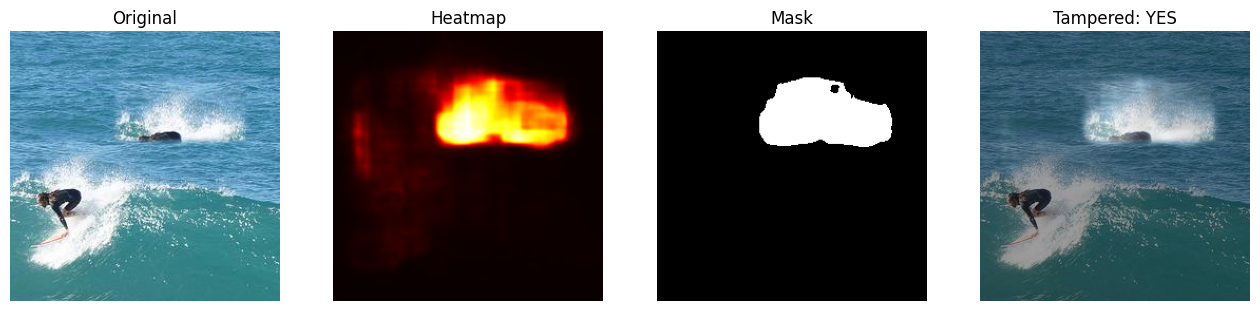

In [16]:
show_result("../dataset/val/images/COCO_DF_C100B00000_00400108.jpg")

In [17]:
def predict_label(heatmap):
    mean_val = heatmap.mean()
    max_val = heatmap.max()
    area = (heatmap > 0.5).sum()

    if (max_val > 0.7) or (area > 1500) or (mean_val > 0.08):
        return 1  # tampered
    else:
        return 0  # real

In [18]:
import pandas as pd

labels = pd.read_csv("../dataset/test/columbia/labels.csv")
test_dir = "../dataset/test/columbia/images"

correct = 0
total = 0

for _, row in labels.iterrows():
    img_path = os.path.join(test_dir, row["filename"])
    true_label = row["label"]

    _, heatmap, _, _ = detect_tampering(img_path)

    pred_label = predict_label(heatmap)

    if pred_label == true_label:
        correct += 1

    total += 1

print(f"Accuracy: {correct/total:.2f}")

Accuracy: 0.69


In [21]:
def detect_tampering(image_path):
    # Read image
    image = cv2.imread(image_path)
    original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = original.shape[:2]

    # Preprocess (128x128 as trained)
    img = cv2.resize(original, (128, 128)) / 255.0
    img = (img - 0.5) / 0.5

    img = torch.tensor(img).permute(2,0,1).unsqueeze(0).float().to(device)

    # Predict
    with torch.no_grad():
        pred = model(img)
        heatmap = torch.sigmoid(pred).cpu().squeeze().numpy()

    # Resize back
    heatmap = cv2.resize(heatmap, (w, h))

    # Smooth
    heatmap = cv2.GaussianBlur(heatmap, (7,7), 0)

    # Clamp
    heatmap = np.clip(heatmap, 0, 1)

    # Mask
    mask = (heatmap > 0.5).astype(np.uint8)

    # Decision logic (fixed)
    mean_val = heatmap.mean()
    max_val = heatmap.max()
    area = mask.sum()

    print(f"Mean: {mean_val:.2f}, Max: {max_val:.2f}, Area: {area}")
    if (max_val > 0.7) and (area > 1500) and (mean_val > 0.1):
        tampered = "YES"
    else:
        tampered = "NO"

    # Overlay
    overlay = (original * 0.6 + (heatmap[..., None]*255)*0.4).astype(np.uint8)

    # Bounding box
    coords = np.column_stack(np.where(mask > 0))
    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        cv2.rectangle(overlay, (x_min, y_min), (x_max, y_max), (255,0,0), 2)

    return original, heatmap, mask, overlay, tampered

Mean: 0.92, Max: 1.00, Area: 166979


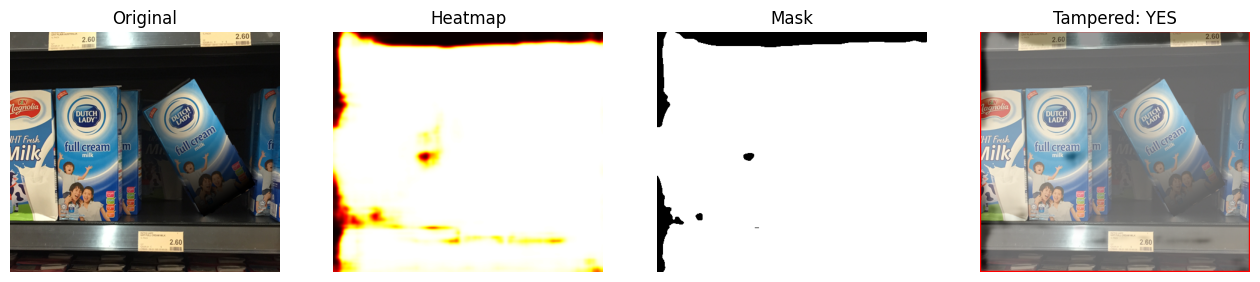

In [22]:
# Replace with your own image path
image_path = "/home/suryakrishnakishore/Documents/Hackbyte/Datasets/coverage/2t.tif"

original, heatmap, mask, overlay, tampered = detect_tampering(image_path)

plt.figure(figsize=(16,5))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(original)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Heatmap")
plt.imshow(heatmap, cmap='hot')
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,4)
plt.title(f"Tampered: {tampered}")
plt.imshow(overlay)
plt.axis("off")

plt.show()

In [71]:
del model
del images
del masks